In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset

# Loading Data
raw_data = load_dataset("lukebarousse/data_jobs")
df = raw_data['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

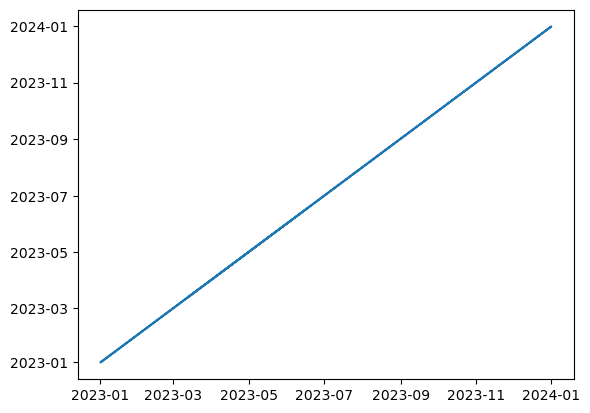

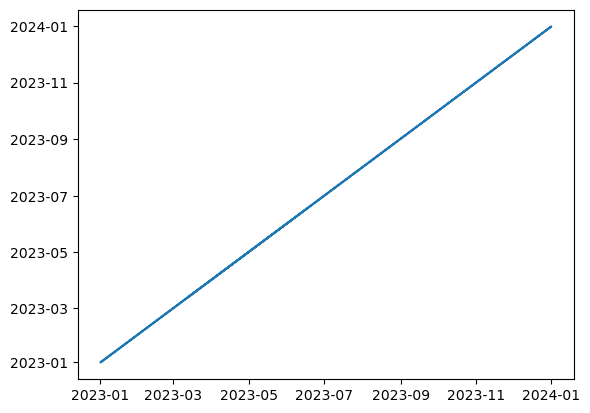

In [2]:
# Printing job_posted_date w.r.t job_posted_date, in 2 different syntaxes

# The below 2 lines of code does the same work, 1st line is general syntax and 2nd one is compressed syntax

# Use subscripting directly
plt.plot(df['job_posted_date'], df['job_posted_date'])
plt.show()

# Use dataframe name as data = <dataFrameName> as @param to .plot()
plt.plot('job_posted_date', 'job_posted_date', data = df)
plt.show()

In [3]:
# Counting unique job_posted_date(s) using groupby, default Ascending Order according to individual INDEX label values, nothing to do with count of each label. Here Index labels are the values of individual dates.
c1 = df.groupby(by = 'job_posted_date')['job_posted_date'].count()
print(c1, end = "\n\n\n________________________________________________\n\n\n")

# Using .value_counts, default Descending Order
c2 = df['job_posted_date'].value_counts()
print(c2, end = "\n\n\n_________________________________________________\n\n\n")

# Calculating count of a specific date using that date as index name
c1_count = c1['2023-12-31 23:40:18']
c2_count = c2['2023-12-31 23:40:18'] # Both are same
print(c1_count, c2_count)


job_posted_date
2023-01-01 00:00:04    1
2023-01-01 00:00:07    1
2023-01-01 00:00:22    1
2023-01-01 00:00:24    1
2023-01-01 00:00:27    1
                      ..
2023-12-31 23:40:18    2
2023-12-31 23:40:22    2
2023-12-31 23:40:31    2
2023-12-31 23:40:32    1
2023-12-31 23:59:58    2
Name: job_posted_date, Length: 607192, dtype: int64


________________________________________________


job_posted_date
2023-12-08 07:24:37    10
2023-01-08 00:19:57    10
2023-09-17 00:28:49    10
2023-09-07 00:07:24    10
2023-07-22 07:25:54    10
                       ..
2023-05-17 17:27:41     1
2023-05-28 17:51:07     1
2023-09-05 17:10:27     1
2023-09-02 17:02:18     1
2023-03-12 06:32:36     1
Name: count, Length: 607192, dtype: int64


_________________________________________________


2 2


X Values (Individual Dates): 
DatetimeIndex(['2023-01-01 00:00:04', '2023-01-01 00:00:07',
               '2023-01-01 00:00:22', '2023-01-01 00:00:24',
               '2023-01-01 00:00:27', '2023-01-01 00:00:38',
               '2023-01-01 00:00:43', '2023-01-01 00:00:51',
               '2023-01-01 00:00:57', '2023-01-01 00:00:59',
               ...
               '2023-12-31 23:40:00', '2023-12-31 23:40:03',
               '2023-12-31 23:40:07', '2023-12-31 23:40:10',
               '2023-12-31 23:40:13', '2023-12-31 23:40:18',
               '2023-12-31 23:40:22', '2023-12-31 23:40:31',
               '2023-12-31 23:40:32', '2023-12-31 23:59:58'],
              dtype='datetime64[ns]', name='job_posted_date', length=607192, freq=None)

Y Values for those X [Count of jobs posted on those dates]: 
[1 1 1 ... 2 1 2]




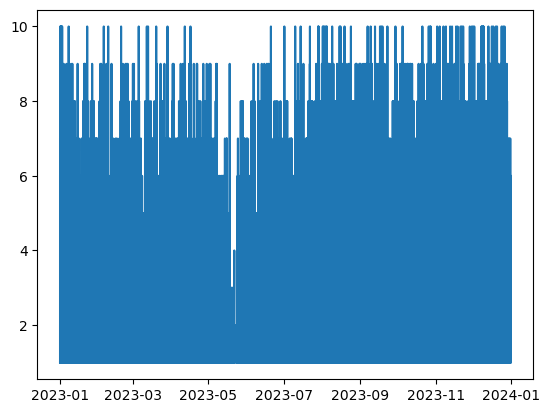



Plotting for Unsorted Index Values: 



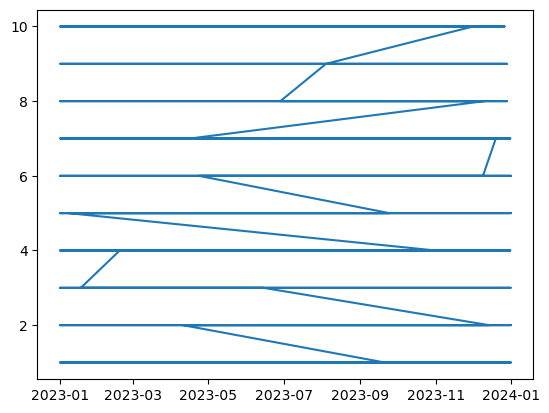

In [4]:
# But we want the counts of job over time.
# What happens if we just aggregated by job_posted_date?
date_count = df['job_posted_date'].value_counts()
sorted_date_count = date_count.sort_index() # Sort by the index values, i.e-> Here index values are the individual values of job_posted_date, nothing to do with individual counts
print("X Values (Individual Dates): \n" + str(sorted_date_count.index)) # Going to be our X axis
print("\nY Values for those X [Count of jobs posted on those dates]: \n" + str(sorted_date_count.values), end = "\n\n\n") # Going to be our Y values for those X

# As both sorted_date_count and date_count are Series Objects now, we can get their indices via .index and values for those indices via .values;
x = sorted_date_count.index
y = sorted_date_count.values

plt.plot(x, y)
plt.show()

print("\n\nPlotting for Unsorted Index Values: \n")
# Plotting in an Unsorted date_count Series
plt.plot(date_count.index, date_count.values)
plt.show()

Count of Jobs posted in each month - 


                 job_posted_month
                            count
job_posted_month                 
1                           91822
2                           64578
3                           64084
4                           62919
5                           52104
6                           61572
7                           63777
8                           75162
9                           62359
10                          66611
11                          64450
12                          56303


Plot to visualize how many job postings were there w.r.t every month ---- 


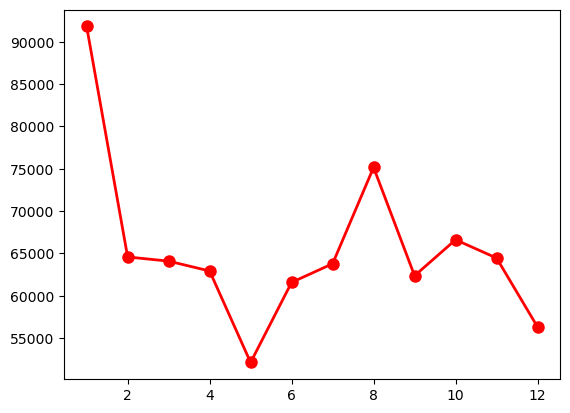

In [5]:
# Sort by putting the job_posted_month as X and their counts as Y

# Create new job_posted_month column
df['job_posted_month'] = df['job_posted_date'].dt.month

# Group by job_posted_month and calculate their counts
month_count = df.groupby(by = ['job_posted_month'])[['job_posted_month']].agg(['count'])
print("Count of Jobs posted in each month - \n\n")
print(month_count)
month_count_sorted = month_count.sort_index() # Not needed as using groupby over valuecounts by default sorts in Ascending Order according to Index

x = month_count_sorted.index
y = month_count_sorted.values

# Plot to visualize how many job postings were there w.r.t every month
print("\n\nPlot to visualize how many job postings were there w.r.t every month ---- ")
plt.plot(x, y, color='red', marker='o',
     linewidth=2, markersize=8)
plt.show()

## Series vs DataFrames in Pandas
### A Series is one of the core data structures in pandas, akin to a one-dimensional array (like in NumPy) BUT with powerful, flexible indexing capabilities.

## Core Characteristics
 1. One-Dimensional: It's essentially a single column of data.
 2. Indexed: Each element in a Series has an associated label, known as the index. The index can be numbers, dates, or even strings.
 3. Diverse Data Types: A Series can hold any data type—integers, strings, floats, Python objects, etc. However, all elements within a Series must be of the same data type. 

In [6]:
import pandas as pd

fruitSeries = pd.Series(["apple", "banana", "mango", "pineapple"])

# By default fruitSeries is fruitSeries.values
print(fruitSeries, end = "\n\n")
print(fruitSeries.index, end = "\n\n")
print(fruitSeries.values, end = "\n\n")

# Change the indices of the series --> Has to make a fruits Array for this
fruitsArray = ["apple", "banana", "mango", "pineapple"]
indexedFruitSeries = pd.Series(fruitsArray, ['appleIndex', 'bananaIndex', 'mangoIndex', 'pineappleIndex'])
print(indexedFruitSeries, end = "\n\n")
# Accesssing via Index
print(indexedFruitSeries['pineappleIndex'])

0        apple
1       banana
2        mango
3    pineapple
dtype: object

RangeIndex(start=0, stop=4, step=1)

['apple' 'banana' 'mango' 'pineapple']

appleIndex            apple
bananaIndex          banana
mangoIndex            mango
pineappleIndex    pineapple
dtype: object

pineapple


### Bar Charts --> Vertical

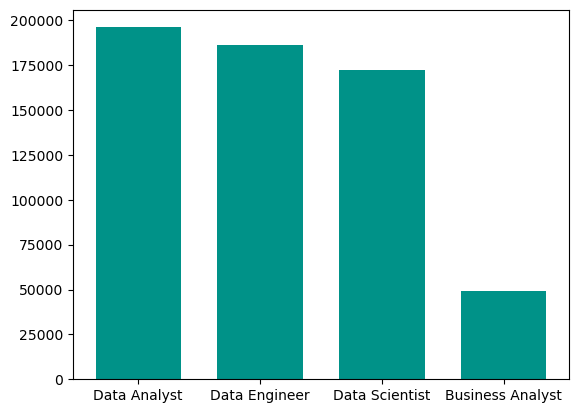

In [23]:
# matplotlib.pyplot.bar(x, height(y), width=0.8, bottom=None, *, align='center', data=None, **kwargs)
# Used for Vertical Bar Charts

# We need to find how many job postings are there for each job_title_short
job_counts = df['job_title_short'].value_counts() # Returns a Series containing job titles as index and their count as values of those indices
x = job_counts.index[0:4]; # Use Slicing to get Top 5 values or directly use .head() after applying value_counts
y = job_counts[0:4];
plt.bar(x, y, width = 0.7, color = "#009288")
plt.show()

# But as there are multiple job_title_short(s), it goes out of view and label names are cluttered !!!

### Bar Charts --> Horizontal

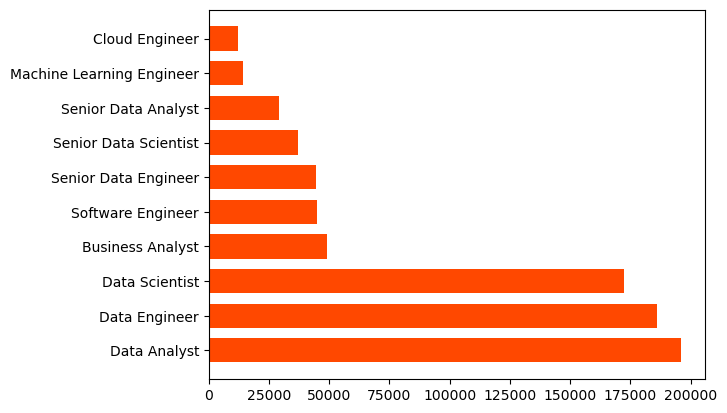

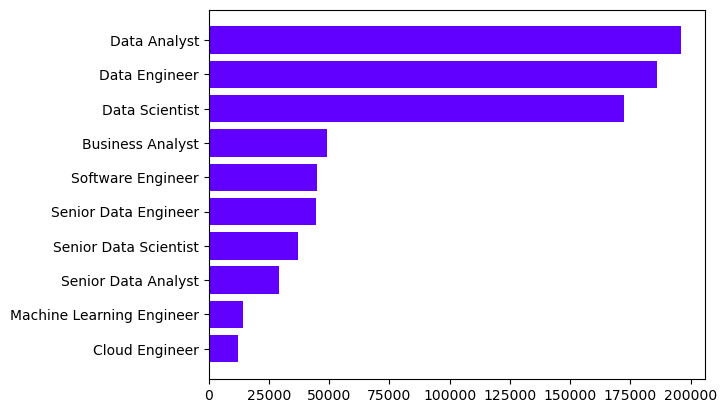

In [ ]:
# matplotlib.pyplot.barh(y, width, height=0.8, left=None, *, align='center', data=None, **kwargs)[source]
# Used for Horizontal Bar Charts
plt.barh(job_counts.index, job_counts, height = 0.7, color = "#FF4800")
plt.show()

# But as the default Sorting order by values is in Descending, we get the Least value of X at top. Visualize where would things end up if we vertically set the X values while plotting Vertical Bar Charts. We will see that the one with least value is at 1st position, if that Axis is put vertically Up, it gets to Last (Top) position

# Sorting in Descending in order to get Highest Values in top, Staricase Pattern
job_counts_sorted = job_counts.sort_values(ascending = True) # SERIES !!!!
# The by parameter is used for DataFrames to tell Pandas which column to look at (e.g., df.sort_values(by='salary')).
#The Series.sort_values() method does not have a by parameter at all because there are no other columns to choose from. So we sort by the values of indices, by default Descending !
plt.barh(job_counts_sorted.index, job_counts_sorted, color = "#6200FF")
plt.show()